In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt giao diện
plt.style.use('ggplot')
sns.set_palette("viridis")

# 1. Nạp dữ liệu
df = pd.read_csv('../data/unprocessed/retail_store_inventory.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Khám phá lỗi logic: Product ID bị gán sai Category
# Đây là phần bạn đã phát hiện và cần đưa vào báo cáo làm minh chứng
product_logic = df.groupby('Product ID')['Category'].nunique()
inconsistent_products = product_logic[product_logic > 1].index
print(f"⚠️ Phát hiện {len(inconsistent_products)} sản phẩm bị loạn danh mục.")

# Tạm thời tạo định danh kép để "nhìn" dữ liệu chính xác hơn trong quá trình khám phá
df['Identity'] = df['Category'] + "-" + df['Product ID']

⚠️ Phát hiện 20 sản phẩm bị loạn danh mục.


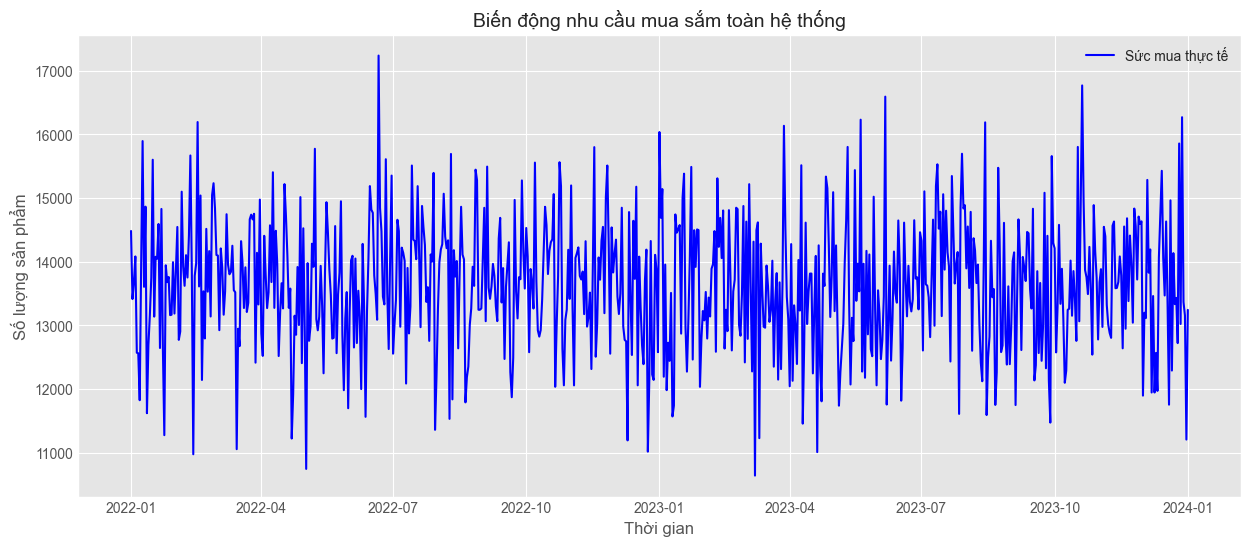

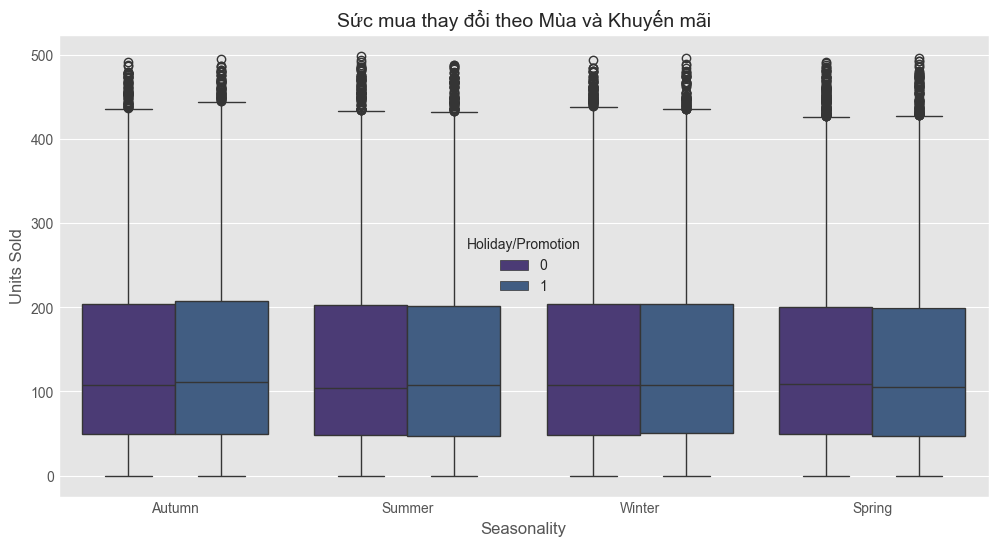

In [36]:
# Biểu đồ xu hướng tổng quát
plt.figure(figsize=(15, 6))
df_daily = df.groupby('Date')['Units Sold'].sum().reset_index()
plt.plot(df_daily['Date'], df_daily['Units Sold'], color='blue', label='Sức mua thực tế')
plt.title('Biến động nhu cầu mua sắm toàn hệ thống', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Số lượng sản phẩm')
plt.legend()
plt.show()

# Khám phá tính mùa vụ (Seasonality)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Seasonality', y='Units Sold', hue='Holiday/Promotion')
plt.title('Sức mua thay đổi theo Mùa và Khuyến mãi', fontsize=14)
plt.show()

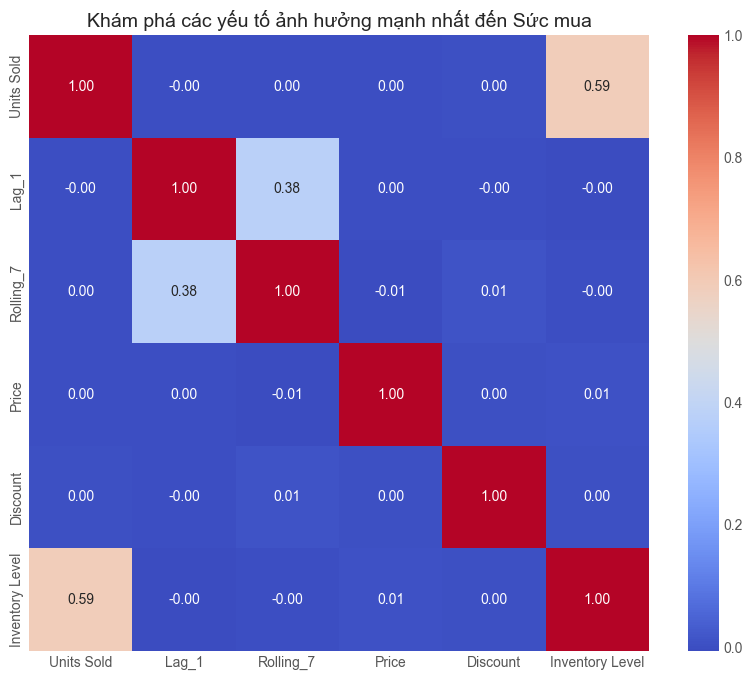

In [37]:
# Tạo các biến thử nghiệm ngay trong EDA để khám phá tương quan
df_temp = df.sort_values(by=['Identity', 'Date']).copy()
df_temp['Lag_1'] = df_temp.groupby('Identity')['Units Sold'].shift(1)
df_temp['Rolling_7'] = df_temp.groupby('Identity')['Units Sold'].transform(lambda x: x.shift(1).rolling(7).mean())

# Vẽ ma trận tương quan
cols_to_check = ['Units Sold', 'Lag_1', 'Rolling_7', 'Price', 'Discount', 'Inventory Level']
corr = df_temp[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Khám phá các yếu tố ảnh hưởng mạnh nhất đến Sức mua', fontsize=14)
plt.show()

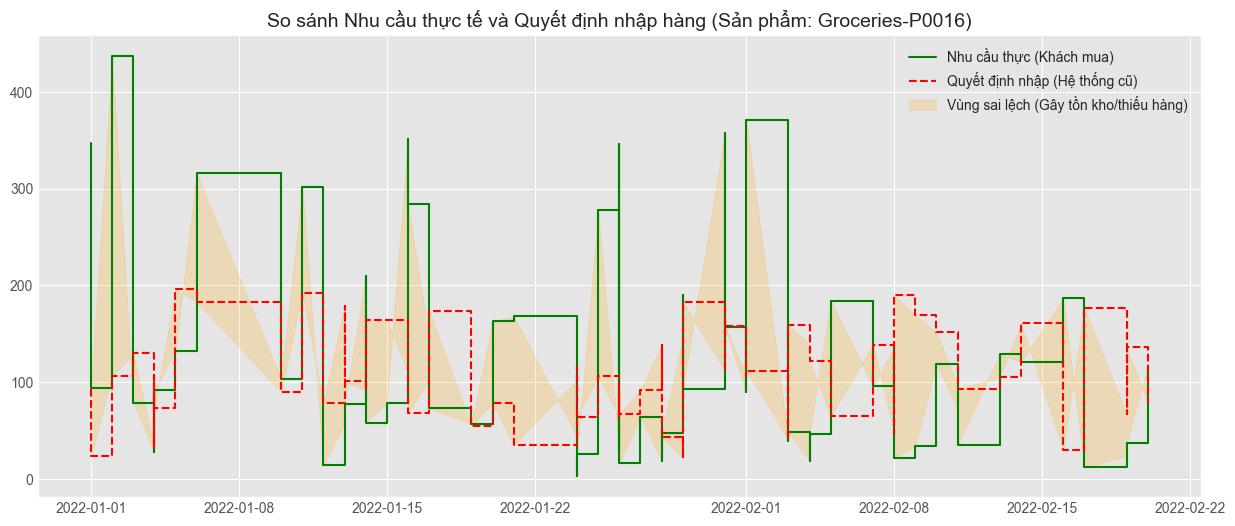

In [38]:
# So sánh Nhu cầu thực tế (Units Sold) và Quyết định nhập hàng (Units Ordered) của hệ thống cũ
plt.figure(figsize=(15, 6))
# Lấy ví dụ 1 sản phẩm bán chạy nhất để so sánh
sample_id = df['Identity'].value_counts().index[0]
sample_data = df[df['Identity'] == sample_id].sort_values('Date').head(60) # Xem 2 tháng

plt.step(sample_data['Date'], sample_data['Units Sold'], label='Nhu cầu thực (Khách mua)', color='green', where='post')
plt.step(sample_data['Date'], sample_data['Units Ordered'], label='Quyết định nhập (Hệ thống cũ)', color='red', linestyle='--', where='post')

plt.title(f'So sánh Nhu cầu thực tế và Quyết định nhập hàng (Sản phẩm: {sample_id})', fontsize=14)
plt.fill_between(sample_data['Date'], sample_data['Units Sold'], sample_data['Units Ordered'], alpha=0.2, color='orange', label='Vùng sai lệch (Gây tồn kho/thiếu hàng)')
plt.legend()
plt.show()